In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

# Load dataset
housing = fetch_california_housing()

# Create DataFrame
df = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)

# Add target column
df["HouseValue"] = housing.target

# Save as CSV
df.to_csv("D:/project/housing model/data/california_housing.csv", index=False)

print("Dataset saved successfully!")

Dataset saved successfully!


In [19]:
import pandas as pd

df = pd.read_csv("D:/project/housing model/data/california_housing.csv")

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   HouseValue  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [21]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HouseValue
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [22]:
df.shape

(20640, 9)

In [23]:
df.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
HouseValue    0
dtype: int64

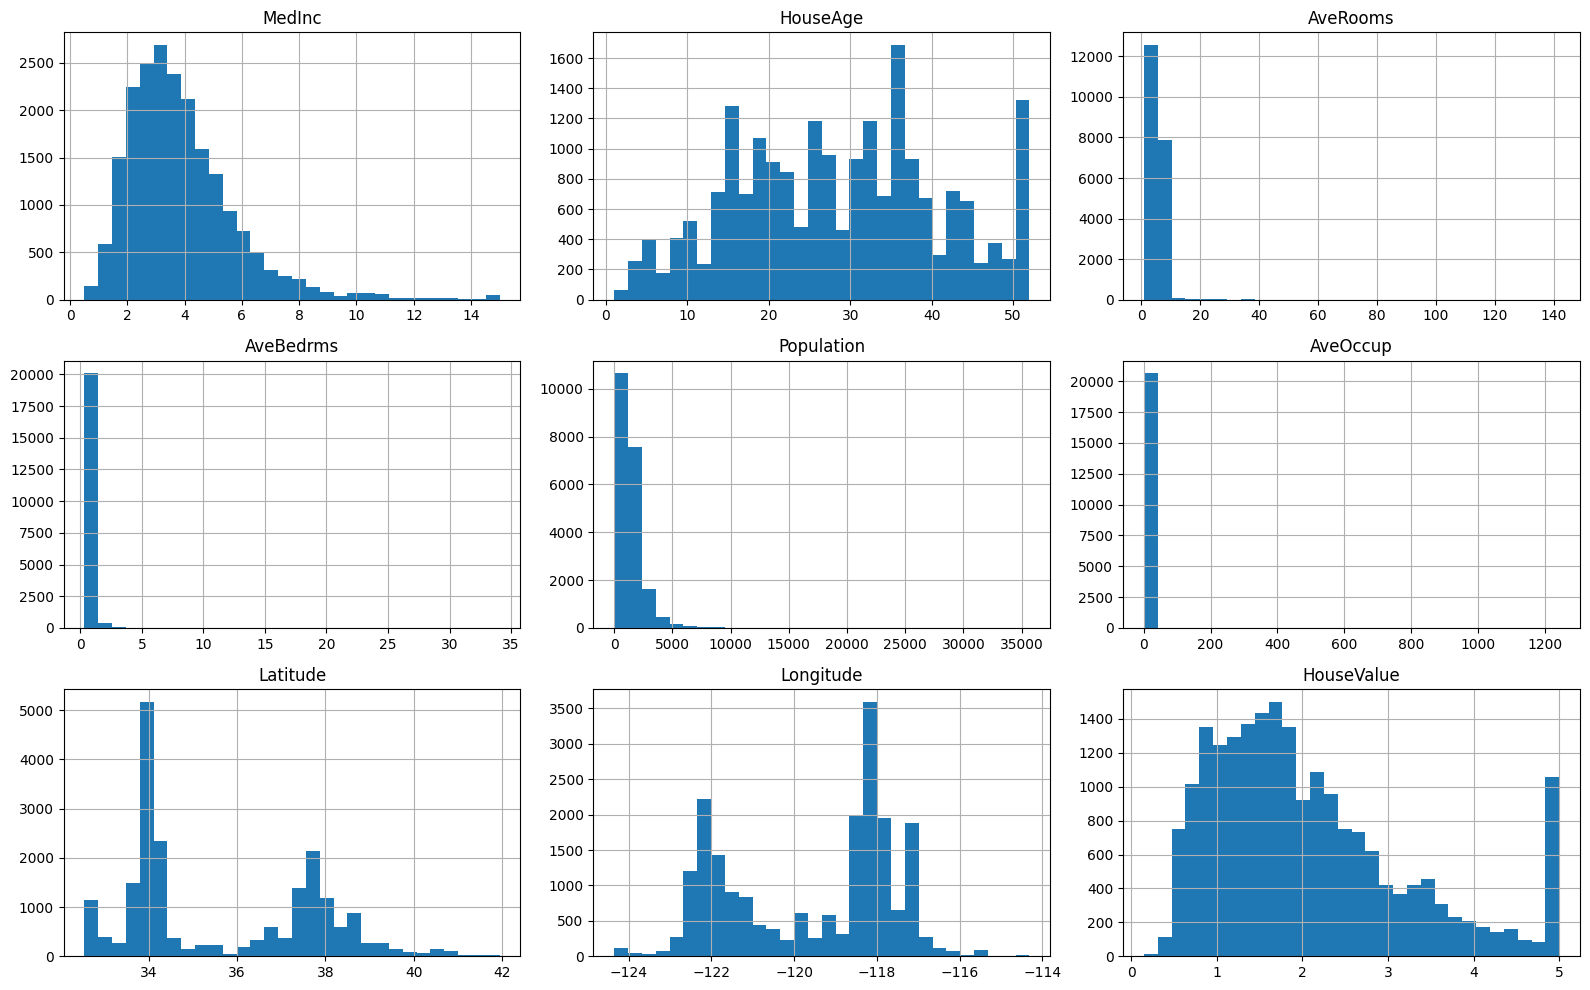

In [24]:
df.hist(figsize=(16,10),bins=30)
plt.tight_layout()
plt.show()

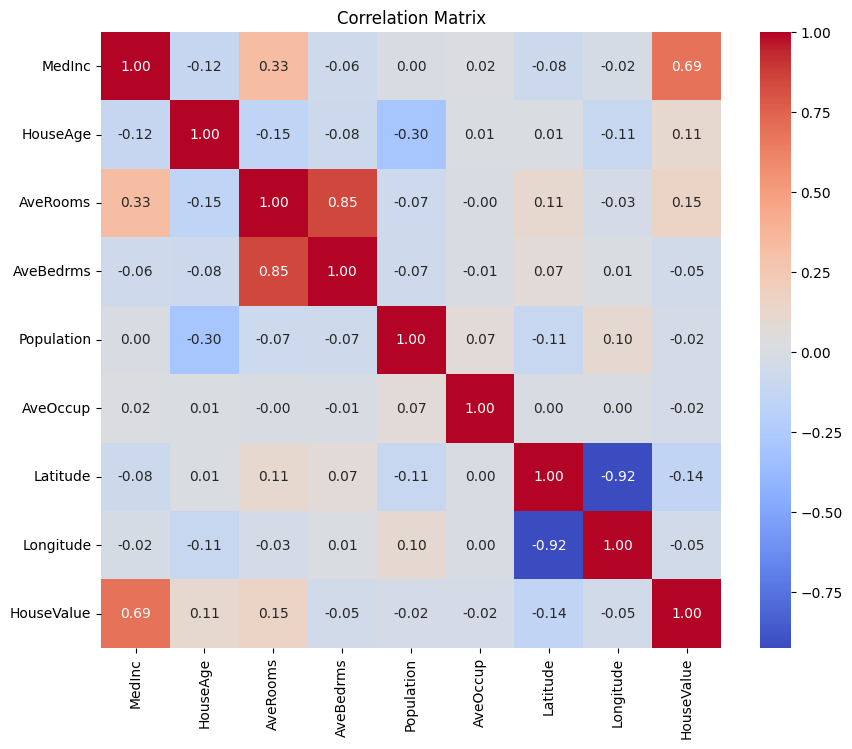

In [25]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

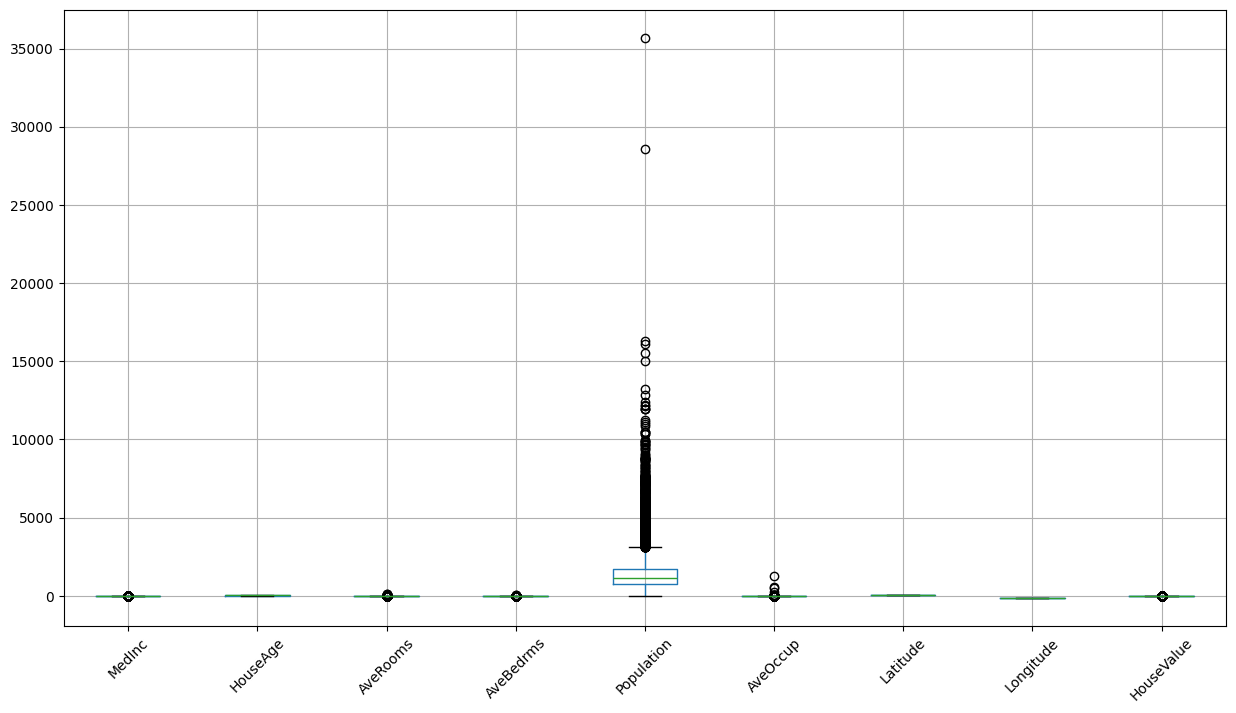

In [26]:
plt.figure(figsize=(15,8))

df.boxplot(rot=45)

plt.show()

In [27]:
# Separate Features and Target
X = df.drop("HouseValue", axis=1)
y = df["HouseValue"]

# Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape: (16512, 8)
Testing Shape : (4128, 8)


In [28]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [29]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coef_df = coef_df.sort_values(
    by="Coefficient",
    key=abs,
    ascending=False
)

coef_df

,Feature,Coefficient
3,AveBedrms,0.783145
0,MedInc,0.448675
7,Longitude,-0.433708
6,Latitude,-0.419792
2,AveRooms,-0.123323
1,HouseAge,0.009724
5,AveOccup,-0.003526
4,Population,-0.000002


In [30]:
y_pred = model.predict(X_test)

In [31]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

MAE  : 0.5332
MSE  : 0.5559
RMSE : 0.7456
R²   : 0.5758


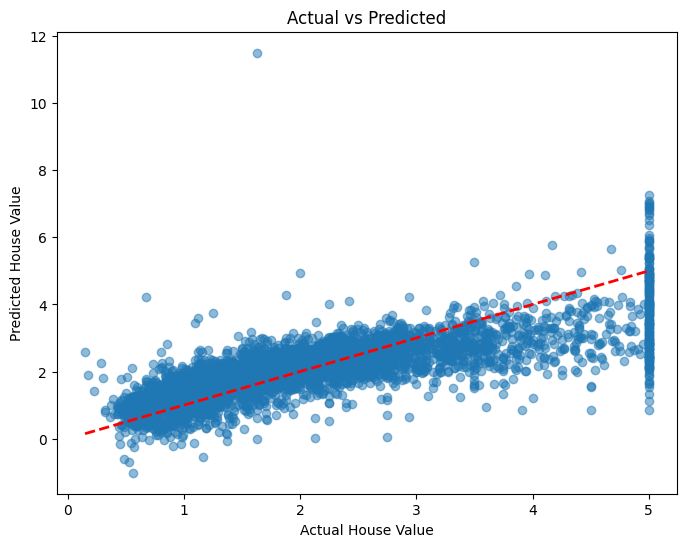

In [32]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted")

plt.show()

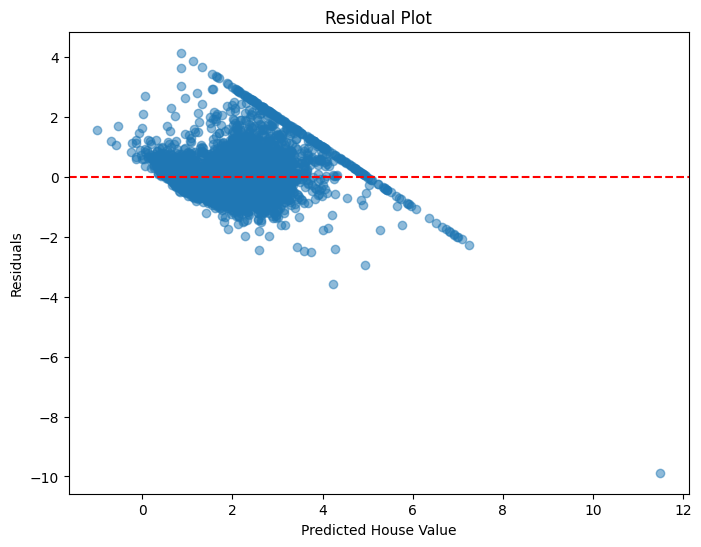

In [33]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))

plt.scatter(y_pred, residuals, alpha=0.5)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted House Value")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

In [35]:
import joblib

joblib.dump(model, "D:/project/housing model/models/linear_regression.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


In [36]:
feature_names = list(X.columns)

joblib.dump(feature_names, "D:/project/housing model/models/features.pkl")

['D:/project/housing model/models/features.pkl']

In [37]:
metrics = {
    "MAE": mae,
    "MSE": mse,
    "RMSE": rmse,
    "R2": r2
}

joblib.dump(metrics, "D:/project/housing model/models/metrics.pkl")

['D:/project/housing model/models/metrics.pkl']

In [39]:
import os

print(os.listdir("D:/project/housing model/models"))

['features.pkl', 'linear_regression.pkl', 'metrics.pkl']
